# 03 -- Isolation by distance

Computes linearized pairwise site-level Fst and regresses against geographic distance.

**Inputs**
- `table_S1.tsv` --> STAGdb metadata for samples included in manuscript
- `mac_ld.gt_matrix.int8.npz` from `convert_vcf_to_npz.py` --> not downsampled, no global MAF filter


**Outputs**
- `apal_ibd.tsv` --> filtered and merged sites for IBD analysis
- `lin_fst_sites.tsv` --> linearized site-level pairwise Fst table
- `ibd_florida.pdf`
- `ibd_greater_antilles.pdf`

---

## Imports and paths

In [6]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path("../scripts")))

from gt_io import load_cache_npz, write_cache_npz, basic_parse_report

from popgen_utils import (
    assign_florida_name_family,
    build_symmetric_pair_matrix,
    compute_ibd_stats_from_long_df,
    dosage_to_genotype_array,
    fst_mat_to_nm_long,
    fst_pair_with_nloci,
    haversine_km,
    linearized_fst,
    mantel_test,
    order_sites_greedy_nn,
)

import plotly.express as px

In [7]:
PROJECT_DIR = Path("/Users/kidelu001/awi-work/science/projects/apal_popgen/github")
# PROJECT_DIR = Path(/path/to/your/project)

# input
META_TSV  = PROJECT_DIR / "table_S1_metadata.tsv"

DATA_DIR = Path("/Users/kidelu001/awi-work/science/projects/apal_popgen/deriv/manuscript")

NPZ = DATA_DIR / "maf_ld_prev.gt_matrix.int8.npz"

------

## IBD functions

In [37]:
def build_panel(apal_ibd, gt, subregion, site_merge_fn=None, site_merge_map=None):
    """
    Filter to subregion, apply site merges, align to NPZ order,
    deduplicate (one sample per MLG × site), filter by min genets,
    and return a trimmed GenotypeArray.

    Parameters
    ----------
    site_merge_fn  : callable  – e.g. assign_florida_name_family
    site_merge_map : dict      – e.g. GA_SITE_MERGE_MAP

    Returns
    -------
    panel       : pd.DataFrame  sample metadata aligned to gta columns
    site_coords : pd.DataFrame  per-site centroid + n_genets
    gta         : allel.GenotypeArray
    """
    panel = apal_ibd[apal_ibd[IBD_COL] == subregion].copy()

    if site_merge_fn is not None:
        panel["site_merged"] = panel[SITE_COL].map(site_merge_fn)
    elif site_merge_map is not None:
        panel["site_merged"] = panel[SITE_COL].map(lambda x: site_merge_map.get(x, x))
    else:
        panel["site_merged"] = panel[SITE_COL]

    # align to NPZ sample order
    npz_lookup = {s: i for i, s in enumerate(gt.sample_ids)}
    panel = panel[panel[ID_COL].isin(npz_lookup)].copy()
    panel["_npz_idx"] = panel[ID_COL].map(npz_lookup)
    panel = panel.sort_values("_npz_idx").reset_index(drop=True)

    # deduplicate: one sample per (MLG, merged site)
    panel = (
        panel
        .drop_duplicates(subset=[MLG_COL, "site_merged"], keep="first")
        .reset_index(drop=True)
    )

    # filter sites by min_genets
    site_n = panel.groupby("site_merged")[MLG_COL].nunique()
    valid  = site_n[site_n >= MIN_GENETS_PER_SITE].index
    panel  = panel[panel["site_merged"].isin(valid)].copy().reset_index(drop=True)

    # site centroids and genet counts
    site_coords = (
        panel.groupby("site_merged")
        .agg(
            lat_median=(LAT_COL, "median"),
            lon_median=(LON_COL, "median"),
            n_genets=(MLG_COL, "nunique"),
        )
        .reset_index()
        .rename(columns={"site_merged": "site"})
    )

    # subset genotype matrix and build GenotypeArray
    G_sub = gt.G[:, panel["_npz_idx"].to_numpy()]
    gta   = dosage_to_genotype_array(G_sub)

    return panel, site_coords, gta


def compute_pairwise_fst(panel, gta):
    """Weir-Cockerham FST for all site pairs. Returns a long DataFrame."""
    sites = sorted(panel["site_merged"].unique())
    rows  = []
    for s1, s2 in itertools.combinations(sites, 2):
        mask1 = (panel["site_merged"] == s1).values
        mask2 = (panel["site_merged"] == s2).values
        fst, n_loci = fst_pair_with_nloci(gta, mask1, mask2)
        rows.append({"site1": s1, "site2": s2, "fst": fst, "n_loci": n_loci})
    return pd.DataFrame(rows)


def build_ibd_df(fst_df, site_coords_ordered):
    """Add linearized FST, geographic distance, and along-tract distance."""
    df       = fst_df.copy()
    df["linearized_fst"] = df["fst"].apply(linearized_fst)
    coord    = site_coords_ordered.set_index("site")[["lat_median", "lon_median", "tract_km"]]

    df["geo_dist_km"]    = df.apply(lambda r: haversine_km(
        coord.loc[r["site1"], "lat_median"], coord.loc[r["site1"], "lon_median"],
        coord.loc[r["site2"], "lat_median"], coord.loc[r["site2"], "lon_median"],
    ), axis=1)
    df["along_tract_km"] = df.apply(lambda r: abs(
        coord.loc[r["site1"], "tract_km"] - coord.loc[r["site2"], "tract_km"]
    ), axis=1)
    return df


def plot_ibd(ibd_df, x_col="geo_dist_km", y_col="linearized_fst",
             title="IBD", save_base=None, figsize=(5, 5)):
    """IBD scatter with OLS regression line and annotated statistics."""
    df   = ibd_df[[x_col, y_col]].dropna()
    x, y = df[x_col].values, df[y_col].values

    ols  = stats.linregress(x, y)
    r2   = ols.rvalue ** 2
    istats = compute_ibd_stats_from_long_df(
        ibd_df, x_col=x_col, y_col=y_col, n_perm=N_MANTEL_PERM
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, s=40, edgecolors="k", linewidths=0.5, alpha=0.8, zorder=3)

    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, ols.slope * xline + ols.intercept, color="0.4", lw=1)

    label = (
        f"$R^2$ = {r2:.3f}  (p = {istats['ols_p']:.3f})\n"
        f"Mantel r = {istats['mantel_r']:.3f}  (p = {istats['mantel_p']:.3f})\n"
        f"n pairs = {istats['n_pairs']}"
    )
    ax.text(0.97, 0.05, label, transform=ax.transAxes, fontsize=8,
            ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9))

    ax.set_xlabel("Geographic distance (km)")
    ax.set_ylabel("$F_{ST}$ / (1 − $F_{ST}$)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()

    if save_base is not None:
        for ext in ("pdf", "eps"):
            fig.savefig(f"{save_base}.{ext}", bbox_inches="tight")
        print(f"Saved → {save_base}.pdf / .eps")

    plt.show()
    return istats

----
## Filter metadata to IBD sites

In [19]:
meta = pd.read_csv(META_TSV, sep="\t", low_memory=False)

,affymetrix_id,species,mlg,region,region_sub,region_fix_reason,reef,lat_old,lon_old,lat_clean,...,sample_id,user_specimen_id,perc_missing_data,perc_heterozygous,perc_acer,perc_apal,seq_facility,organization,Unnamed: 23,collection_date
0,121170171_(Axiom_AcropSNP)_K05.CEL,A.palmata,HG1491,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,...,A12725,9334,0.17,0.63,0.54,98.80,Eurofins,Penn State,NaN,1/13/08
1,121170195_(Axiom_AcropSNP)_O05.CEL,A.palmata,HG1495,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,...,A12749,9345,0.20,0.64,0.67,98.63,Eurofins,Penn State,NaN,1/13/08
2,121170183_(Axiom_AcropSNP)_M05.CEL,A.palmata,HG1498,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,...,A12737,9335,0.20,1.03,0.40,98.51,Eurofins,Penn State,NaN,1/13/08
3,121166503_(Axiom_AcropSNP)_A05.CEL,A.palmata,HG1544,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.14600,23.80219,...,A12761,1643,0.21,0.56,0.36,99.01,Eurofins,Penn State,NaN,2/3/03
4,121166539_(Axiom_AcropSNP)_G05.CEL,A.palmata,HG1550,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.14600,23.80219,...,A12797,1658,0.21,0.34,0.41,99.18,Eurofins,Penn State,NaN,2/3/03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,325318639_(Axiom_AcropSNP)_A05.CEL,A.palmata,HG2656,USVI,USVI,NaN,Sugar Beach,17.76005,-64.71513,17.76005,...,A16830,APAL628,1.29,1.28,0.54,97.48,EuroFins,The Nature Conservancy,NaN,10/9/25
4000,325318637_(Axiom_AcropSNP)_M03.CEL,A.palmata,HG2629,USVI,USVI,NaN,Sugar Beach,17.76011,-64.71713,17.76011,...,A16828,APAL623,0.70,0.70,0.51,98.49,EuroFins,The Nature Conservancy,NaN,10/9/25
4001,325318636_(Axiom_AcropSNP)_K03.CEL,A.palmata,HG2629,USVI,USVI,NaN,Sugar Beach,17.76018,-64.71717,17.76018,...,A16827,APAL622,0.79,0.75,0.52,98.40,EuroFins,The Nature Conservancy,NaN,10/9/25
4002,325318638_(Axiom_AcropSNP)_O03.CEL,A.palmata,HG2652,USVI,USVI,NaN,Sugar Beach,17.76022,-64.71649,17.76022,...,A16829,APAL626,0.70,0.99,0.51,98.18,EuroFins,The Nature Conservancy,NaN,10/9/25


In [23]:
ID_COL          = "affymetrix_id"
SPECIES_COL     = "species"
MLG_COL         = "mlg"
REGION_COL      = "region"
SUBREGION_COL   = "region_sub"
REEF_COL        = "reef"
LAT_COL         = "lat_clean"
LON_COL         = "lon_clean"
NURSERY_COL     = "is_nursery"
 

In [25]:
apal_wild = meta.loc[
    ~meta[NURSERY_COL]
].copy().reset_index(drop=True)

apal_wild.shape

(2632, 25)

In [29]:
apal_wild['subregion_ibd'] = 'Exclude'

florida_regions = ['Florida']
grant_regions = ['Dominican Republic', 'Puerto Rico', 'USVI']

apal_wild.loc[apal_wild[REGION_COL].isin(florida_regions), 'subregion_ibd'] = 'Florida'
apal_wild.loc[apal_wild[REGION_COL].isin(grant_regions), 'subregion_ibd'] = 'GreaterAntilles'

apal_wild['subregion_ibd'].value_counts(dropna=False)


subregion_ibd
Florida            1453
Exclude             608
GreaterAntilles     571
Name: count, dtype: int64

----
## Greater Antilles

In [66]:
grant_df = apal_wild.loc[
    apal_wild["subregion_ibd"] == "GreaterAntilles"
].copy().reset_index(drop=True)

In [68]:
grant_site_counts = (
    grant_df.groupby([SUBREGION_COL, REEF_COL], dropna=False)
    .agg(
        # n_rows=(ID_COL, "size"),
        n_genets=(MLG_COL, lambda s: s.nunique(dropna=True)),
        lat_clean=(LAT_COL, "median"),
        lon_clean=(LON_COL, "median"),
    )
    .reset_index()
    .sort_values(["n_genets", SUBREGION_COL, REEF_COL], ascending=[False, True, True])
    .reset_index(drop=True)
)

grant_site_counts

,region_sub,reef,n_genets,lat_clean,lon_clean
0,Puerto Rico,Gilligan's Reef,29,17.939170,-66.869200
1,Dominican Republic,PuntaCana,28,18.527480,-68.357600
2,USVI,Buck Island,19,17.780760,-64.587480
3,USVI,Rust Op Twist,17,17.782790,-64.792010
4,Dominican Republic,Catalina,16,18.376290,-69.008500
5,Dominican Republic,Minitas,16,18.401240,-68.920900
6,Puerto Rico,Cayo Lajas,15,17.937500,-66.899400
7,Puerto Rico,Cayo Coral HMO5,14,17.937620,-66.890900
8,Puerto Rico,Laurel,14,17.941900,-67.057500
9,Puerto Rico,Penon Moncho Diaz,14,18.472240,-66.478700


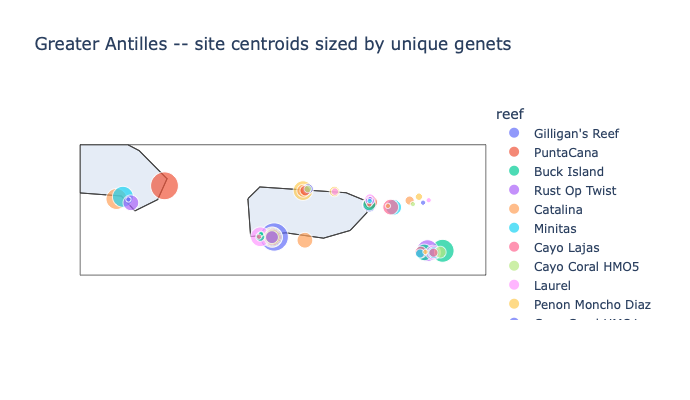

In [80]:
fig = px.scatter_geo(
    grant_site_counts,
    lat=LAT_COL,
    lon=LON_COL,
    color=REEF_COL,
    size="n_genets",
    hover_name=SUBREGION_COL,
    hover_data=[SUBREGION_COL, REEF_COL, "n_genets"],
    title="Greater Antilles -- site centroids sized by unique genets",
)

fig.update_geos(
    scope="world",
    projection_type="natural earth",
    showcountries=True,
    showcoastlines=True,
    lataxis_range=[17.5, 19.0],
    lonaxis_range=[-69.5, -64.0],
)

fig.update_layout(height=400)
fig.show()

In [73]:
grant_df["merged_site"] = grant_df[REEF_COL]

In [74]:
# Greater Antilles

GA_SITE_MERGE_MAP = {
    # Dominican Republic
    "Minitas":  "DR_Minitas_Catalina",
    "Catalina": "DR_Minitas_Catalina",

    # Puerto Rico: Laurel / San Cristobal cluster
    "Laurel":                  "PR_Laurel_SanCristobal",
    "San Cristobal":           "PR_Laurel_SanCristobal",
    "San Cristobal Forereef":  "PR_Laurel_SanCristobal",

    # Puerto Rico: Cayo Largo / Palomino cluster
    "Cayo Largo Norte":       "PR_CayoLargo_Palomino",
    "Cayo Largo North":       "PR_CayoLargo_Palomino",
    "Cayo Largo Sur":         "PR_CayoLargo_Palomino",
    "Cayo Largo South":       "PR_CayoLargo_Palomino",
    "Wave Attenuation Site":  "PR_CayoLargo_Palomino",
    "Lobos":                  "PR_CayoLargo_Palomino",
    "Palomino (Sand Slide )": "PR_CayoLargo_Palomino",

    # Puerto Rico: individual consolidated sites
    "Gilligan's Reef":  "PR_Gilligans",
    "Cayo Lajas":       "PR_CayoLajas",
    "Coral Uberbs":     "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO1":  "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO4":  "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO5":  "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO9":  "PR_CayoCoral_Uberbs",
}

In [75]:
ga_panel, ga_sites, ga_gta = build_panel(
    apal_ibd, gt,
    subregion="GreaterAntilles",
    site_merge_map=GA_SITE_MERGE_MAP,
)

print(f"{ga_panel['site_merged'].nunique()} sites | {ga_panel[MLG_COL].nunique()} genets")
ga_sites.sort_values("n_genets", ascending=False)

19 sites | 276 genets


,site,lat_median,lon_median,n_genets
7,PR_CayoCoral_Uberbs,17.937500,-66.89090,39
15,PuntaCana,18.527480,-68.35760,28
10,PR_Gilligans,17.939170,-66.86920,25
9,PR_CayoLargo_Palomino,18.314500,-65.57900,24
2,Buck Island,17.781190,-64.58868,19
4,DR_Minitas_Catalina,18.401240,-68.92090,17
11,PR_Laurel_SanCristobal,17.941900,-67.05750,17
8,PR_CayoLajas,17.937500,-66.89940,15
17,Rust Op Twist,17.782745,-64.79205,14
12,Penon Moncho Diaz,18.472240,-66.47870,14


In [78]:
ga_sites_ordered = order_sites_greedy_nn(ga_sites)
ga_ibd_df = build_ibd_df(ga_fst_df, ga_sites_ordered)

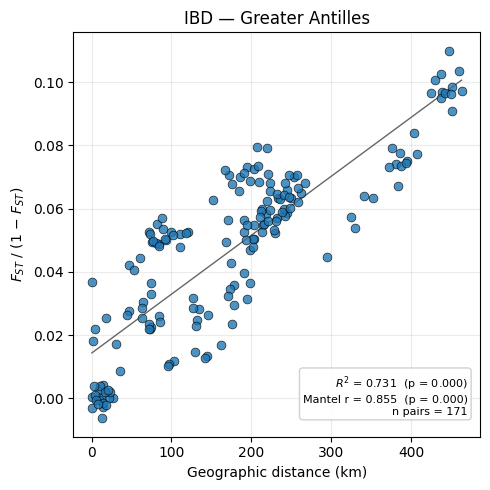

{'x_col': 'geo_dist_km',
 'n_pairs': 171,
 'slope': np.float64(0.00018630699904568005),
 'intercept': np.float64(0.014323185864306115),
 'ols_r2': np.float64(0.7309745979804929),
 'ols_p': np.float64(4.699008627354543e-50),
 'mantel_r': 0.8549705246267225,
 'mantel_p': 9.999000099990002e-05}

In [77]:
ga_stats = plot_ibd(
    ga_ibd_df,
    x_col="geo_dist_km",
    title="IBD — Greater Antilles",
    save_base=None,
)
ga_stats

In [12]:
ID_COL   = "affymetrix_id"
MLG_COL  = "mlg"
SITE_COL = "reef"
LAT_COL  = "lat_clean"
LON_COL  = "lon_clean"
IBD_COL  = "subregion_ibd"

MIN_GENETS_PER_SITE = 5
N_MANTEL_PERM       = 10_000

In [53]:
apal_ibd = apal_wild.copy()
gt = load_cache_npz(str(NPZ))

print(f"Metadata : {len(apal_ibd):,} samples")
print(f"NPZ      : {gt.G.shape[0]:,} SNPs × {gt.G.shape[1]:,} samples")

apal_ibd[IBD_COL].value_counts()

Metadata : 2,632 samples
NPZ      : 3,535 SNPs × 976 samples


subregion_ibd
Florida            1453
Exclude             608
GreaterAntilles     571
Name: count, dtype: int64

---
## Florida panel

In [54]:
fl_panel, fl_sites, fl_gta = build_panel(
    apal_ibd, gt,
    subregion="Florida",
    site_merge_fn=popgen_utils.assign_florida_name_family,
)

print(f"{fl_panel['site_merged'].nunique()} sites | {fl_panel[MLG_COL].nunique()} genets")
fl_sites.sort_values("lon_median")

15 sites | 142 genets


,site,lat_median,lon_median,n_genets
12,Sand Key,24.452350,-81.877200,5
8,Looe,24.546930,-81.407700,11
13,Sombrero Reef,24.625820,-81.110400,12
14,Unknown,24.662919,-81.007571,10
3,Conch,24.982800,-80.436000,6
10,Pickles Reef,24.985450,-80.417050,5
9,Molasses,25.009617,-80.374700,13
11,Sand Island,25.018219,-80.368487,5
6,French Reef,25.035031,-80.349058,12
7,Grecian Rocks,25.111960,-80.303313,6


In [55]:
fl_fst_df = compute_pairwise_fst(fl_panel, fl_gta)
print(f"{len(fl_fst_df)} site pairs | FST range: "
      f"{fl_fst_df['fst'].min():.4f} – {fl_fst_df['fst'].max():.4f}")
fl_fst_df.head()

105 site pairs | FST range: -0.0077 – 0.0594


,site1,site2,fst,n_loci
0,Ball Buoy,Broward County,0.016190,3314
1,Ball Buoy,Carysfort,0.023422,3459
2,Ball Buoy,Conch,0.030005,3366
3,Ball Buoy,Dry Rocks,0.023224,3460
4,Ball Buoy,Elbow,0.017985,3439


In [56]:
fl_sites_ordered = order_sites_greedy_nn(fl_sites)
fl_ibd_df = build_ibd_df(fl_fst_df, fl_sites_ordered)
fl_ibd_df.head()

,site1,site2,fst,n_loci,linearized_fst,geo_dist_km,along_tract_km
0,Ball Buoy,Broward County,0.016190,3314,0.016457,100.029382,100.029382
1,Ball Buoy,Carysfort,0.023422,3459,0.023984,10.900167,10.900167
2,Ball Buoy,Conch,0.030005,3366,0.030933,44.695811,47.146004
3,Ball Buoy,Dry Rocks,0.023224,3460,0.023776,24.176127,25.273543
4,Ball Buoy,Elbow,0.017985,3439,0.018315,20.417348,20.625338


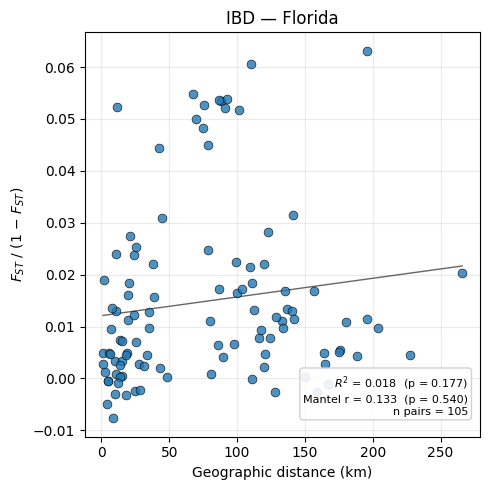

{'x_col': 'geo_dist_km',
 'n_pairs': 105,
 'slope': np.float64(3.600275318477471e-05),
 'intercept': np.float64(0.012104673445882137),
 'ols_r2': np.float64(0.01761345501253076),
 'ols_p': np.float64(0.17713451673523656),
 'mantel_r': 0.1327156924125055,
 'mantel_p': 0.5402459754024598}

In [58]:
fl_stats = plot_ibd(
    fl_ibd_df,
    x_col="geo_dist_km",
    title="IBD — Florida",
    save_base=None,
)
fl_stats